# Subscription-Trajectory Classification - 02 · Two-Stage (renew -> movement)

**Idea.** Instead of predicting the 4-class `label` directly, decompose the problem
the way the business decision actually factors:

1. **Stage 1 - renewal (binary).** Predict `renewed` (1 = the subscription renews,
   0 = `CHURN`). This is a clean split: `renewed == 0` is exactly `CHURN`, and
   `renewed == 1` is exactly one of `CONTRACTION / STABLE / EXPANSION`.
2. **Stage 2 - movement (3-class).** *Among renewers*, predict the volume
   trajectory `CONTRACTION / STABLE / EXPANSION`.

We then **derive the 4-class outcome** by composing calibrated probabilities:

$$P(\text{CHURN}) = 1 - P(\text{renew}), \qquad
   P(\text{move}=k) = P(\text{renew})\cdot P_2(k)$$

and take the arg-max (or a tuned renewal threshold). The headline question: **does
   staging beat the direct multiclass model** from notebook 01?

**Protocol (airtight repeated holdout).** Sections 1-6 walk through the pipeline once
on a single split for exposition; the **headline numbers come from the repeated-holdout
evaluation in §7**. There, for each of `U.RUN_SEEDS` we re-derive a fresh user-grouped
15% holdout and 5 folds (`U.assign_run_split`, identical to notebook 01 for the same
seed), **re-tune both stages from scratch on that run's dev users**, tune the renewal
threshold τ on leakage-free dev OOF, refit on all dev users, and evaluate once on the
run's untouched holdout. A **direct** comparator is refit on the same run's dev
(reusing the shared per-seed `direct_lgbm_run{seed}` tuning), so the two-stage-vs-direct
comparison is paired and leakage-free within every run. Scores are reported as
**mean ± standard error** over the runs. No `leakage_cols` ever enter `X`.


In [1]:
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings('ignore')
import time, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
import clf_utils as U
print('model classes  :', U.MODEL_CLASSES)
print('movement classes:', U.MOVEMENT_CLASSES)

model classes  : ['CHURN', 'CONTRACTION', 'STABLE', 'EXPANSION']
movement classes: ['CONTRACTION', 'STABLE', 'EXPANSION']


## 1 · Load data & assemble both targets

One row per `(msno, expiry_event)`, modellable rows only. We build the same
leakage-guarded base feature matrix and derive two targets: `renewed` (stage 1)
and the movement code (stage 2, valid on renewers). An assertion locks in the
`renewed == 0 <-> CHURN` identity.

In [2]:
df = U.load_events('base', modellable_only=True)
X  = U.build_X(df, 'base')
y_multi = U.y_multiclass(df)
y_renew = df['renewed'].to_numpy().astype(int)

# Contract check: renewed==0 is exactly CHURN, renewed==1 is exactly the 3 movement classes
chk = pd.crosstab(df['renewed'], df['label'])
assert chk.loc[0, 'CHURN'] == (y_renew == 0).sum() and chk.drop(columns='CHURN').loc[0].sum() == 0
assert chk.loc[1, 'CHURN'] == 0
print('rows:', f'{len(df):,}', '| features:', X.shape[1])
print('renewal rate (dev):  %.4f' % y_renew[U.dev_mask(df)].mean())
print('movement balance among renewers (dev):')
print(df.loc[U.dev_mask(df) & (df['renewed']==1), 'label'].value_counts(normalize=True).round(4))

rows: 3,784,500 | features: 29
renewal rate (dev):  0.9576
movement balance among renewers (dev):
label
STABLE         0.6588
EXPANSION      0.1806
CONTRACTION    0.1606
Name: proportion, dtype: float64


## 2 · Splits, model adapters & per-stage subsamples

LightGBM is the workhorse here (it ties XGBoost on notebook 01, and is faster across
the many per-stage sweeps); a one-hot logistic regression is the per-stage baseline. We carve a label-stratified dev subsample for the sweeps,
plus a **renewer-only** subsample for stage 2 (folds stay user-disjoint).

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score
from lightgbm import LGBMClassifier

CATS = U.categorical_columns(X)
NUMS = U.numeric_columns(X)

def make_lgbm(**kw):
    params = dict(n_estimators=400, learning_rate=0.05, num_leaves=63,
                  class_weight='balanced', n_jobs=-1, random_state=U.RANDOM_STATE, verbose=-1)
    params.update(kw)
    return LGBMClassifier(**params)

def make_logit():
    num = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
    cat = OneHotEncoder(handle_unknown='ignore', min_frequency=50)
    pre = ColumnTransformer([('num', num, NUMS), ('cat', cat, CATS)])
    return Pipeline([('pre', pre),
                     ('clf', LogisticRegression(max_iter=300, class_weight='balanced'))])

def fit_default(m, Xt, yt): m.fit(Xt, yt); return m

def run_cv(make, fitfn, dfs, Xs, ys, n_folds=3):
    f1s, bals, t0 = [], [], time.time()
    for k, (tr, va) in enumerate(U.cv_folds(dfs)):
        if k >= n_folds: break
        m = fitfn(make(), Xs.iloc[tr], ys[tr])
        p = np.asarray(m.predict(Xs.iloc[va])).astype(int)
        f1s.append(f1_score(ys[va], p, average='macro'))
        bals.append(balanced_accuracy_score(ys[va], p))
    return dict(macro_f1=float(np.mean(f1s)), macro_f1_std=float(np.std(f1s)),
                balanced_acc=float(np.mean(bals)), secs=round(time.time()-t0, 1))

LGBM_GRID = dict(n_estimators=[300, 500, 800], learning_rate=[0.03, 0.05, 0.1],
                 num_leaves=[31, 63, 127, 255], min_child_samples=[20, 50, 100, 200],
                 colsample_bytree=[0.7, 0.85, 1.0], subsample=[0.7, 0.85, 1.0],
                 reg_lambda=[0.0, 1.0, 5.0])

def lgbm_sweep(name, dfs_, Xs_, ys_, n_trials=16, seed=U.RANDOM_STATE, force=False):
    if U.has_sweep(name) and not force:
        c = U.load_sweep(name)
        print('loaded cached sweep %-18s best macroF1=%.4f' % (name, c['best_score']))
        return c['best_params'], pd.read_csv(U.SWEEP_DIR / f'{name}_trials.csv')
    rng = np.random.default_rng(seed); trials = []
    for i in range(n_trials):
        cfg = {k: rng.choice(v).item() for k, v in LGBM_GRID.items()}
        r = run_cv(lambda: make_lgbm(**dict(cfg, subsample_freq=1)), fit_default, dfs_, Xs_, ys_, n_folds=3)
        r.update(cfg); trials.append(r)
        print(f"  trial {i:02d} macroF1={r['macro_f1']:.4f}")
    tdf = pd.DataFrame(trials).sort_values('macro_f1', ascending=False).reset_index(drop=True)
    bp = {k: tdf.iloc[0][k] for k in LGBM_GRID}
    for k in ('n_estimators', 'num_leaves', 'min_child_samples'): bp[k] = int(bp[k])
    bp['subsample_freq'] = 1
    U.save_sweep(name, bp, float(tdf.iloc[0]['macro_f1']), results=tdf.to_dict('records'),
                 meta={'n_trials': n_trials, 'subsample': int(len(dfs_)), 'cv_folds': 3})
    print('saved sweep cache:', name)
    return bp, tdf

# dev subsamples (stage 1 over all dev; stage 2 over renewers only)
dev = df[U.dev_mask(df)].reset_index(drop=True)
Xdev = X[U.dev_mask(df)].reset_index(drop=True)
ymdev = U.y_multiclass(dev)
yrdev = dev['renewed'].to_numpy().astype(int)
s1 = U.stratified_subsample(dev, ymdev, 200_000)
dfs, Xs, ys_renew = dev.iloc[s1].reset_index(drop=True), Xdev.iloc[s1].reset_index(drop=True), yrdev[s1]

dev_r = dev[yrdev == 1].reset_index(drop=True)
Xdev_r = Xdev[yrdev == 1].reset_index(drop=True)
ymove_dev = U.y_movement(dev_r)
s2 = U.stratified_subsample(dev_r, ymove_dev, 200_000)
dfs2, Xs2, ys_move = dev_r.iloc[s2].reset_index(drop=True), Xdev_r.iloc[s2].reset_index(drop=True), ymove_dev[s2]
print('stage-1 subsample:', f'{len(dfs):,}', '| stage-2 (renewers) subsample:', f'{len(dfs2):,}')

stage-1 subsample: 200,001 | stage-2 (renewers) subsample: 200,001


## 3 · Stage 1 - renewal (binary)

Baseline logistic vs a cached LightGBM sweep, scored by macro-F1 over the two
renewal classes (balanced, so the rare `CHURN` side counts).

In [4]:
b1 = run_cv(make_logit, fit_default, dfs, Xs, ys_renew, n_folds=3)
print('logistic baseline  macroF1=%.4f  balAcc=%.4f' % (b1['macro_f1'], b1['balanced_acc']))
renew_params, renew_sweep = lgbm_sweep('twostage_renew', dfs, Xs, ys_renew, n_trials=16)
print('stage-1 best macroF1=%.4f' % renew_sweep.iloc[0]['macro_f1'])
print('stage-1 best params:', renew_params)
renew_sweep.head(8).round(4)

logistic baseline  macroF1=0.6018  balAcc=0.8359
  trial 00 macroF1=0.7078
  trial 01 macroF1=0.6616
  trial 02 macroF1=0.7110
  trial 03 macroF1=0.7103
  trial 04 macroF1=0.6848
  trial 05 macroF1=0.7173
  trial 06 macroF1=0.6739
  trial 07 macroF1=0.6974
  trial 08 macroF1=0.6921
  trial 09 macroF1=0.6995
  trial 10 macroF1=0.6885
  trial 11 macroF1=0.6892
  trial 12 macroF1=0.6810
  trial 13 macroF1=0.7096
  trial 14 macroF1=0.7147
  trial 15 macroF1=0.7097
saved sweep cache: twostage_renew
stage-1 best macroF1=0.7173
stage-1 best params: {'n_estimators': 300, 'learning_rate': np.float64(0.1), 'num_leaves': 255, 'min_child_samples': 50, 'colsample_bytree': np.float64(0.85), 'subsample': np.float64(0.7), 'reg_lambda': np.float64(5.0), 'subsample_freq': 1}


,macro_f1,macro_f1_std,balanced_acc,secs,n_estimators,learning_rate,num_leaves,min_child_samples,colsample_bytree,subsample,reg_lambda
0,0.7173,0.0037,0.7588,40.4,300,0.10,255,50,0.85,0.70,5.0
1,0.7147,0.0033,0.8211,64.1,500,0.03,255,20,1.00,0.70,5.0
2,0.7110,0.0052,0.7120,47.2,800,0.10,127,20,1.00,0.85,1.0
3,0.7103,0.0006,0.8345,57.8,500,0.03,255,200,0.85,0.85,5.0
4,0.7097,0.0050,0.7258,55.4,800,0.10,127,50,1.00,0.70,5.0
5,0.7096,0.0007,0.7962,31.1,800,0.10,63,200,0.70,0.70,5.0
6,0.7078,0.0023,0.8084,17.3,300,0.10,127,50,0.85,1.00,0.0
7,0.6995,0.0034,0.8388,30.4,800,0.05,63,200,0.85,0.70,1.0


## 4 · Stage 1 final - held-out users

Refit on all development users; report ROC-AUC / PR-AUC (renewal is the positive
class) and the macro-F1 of the renew/churn decision at the default 0.5 cut.

In [5]:
mask_dev, mask_ho = U.dev_mask(df), U.holdout_mask(df)
Xtr, Xho = X[mask_dev], X[mask_ho]
yr_tr = df.loc[mask_dev, 'renewed'].to_numpy().astype(int)
yr_ho = df.loc[mask_ho, 'renewed'].to_numpy().astype(int)

t0 = time.time(); stage1 = make_lgbm(**renew_params).fit(Xtr, yr_tr)
print('stage-1 fit on', f'{len(yr_tr):,}', 'rows in', round(time.time()-t0, 1), 's')
p_renew_ho = stage1.predict_proba(Xho)[:, 1]
pred_renew_ho = (p_renew_ho >= 0.5).astype(int)
print('renewal ROC-AUC: %.4f | PR-AUC: %.4f' % (
    roc_auc_score(yr_ho, p_renew_ho), average_precision_score(yr_ho, p_renew_ho)))
print('renew/churn macro-F1 @0.5: %.4f' % f1_score(yr_ho, pred_renew_ho, average='macro'))
print('CHURN (renewed=0) recall @0.5: %.4f' % f1_score(1-yr_ho, 1-pred_renew_ho, average='binary'))

stage-1 fit on 3,215,995 rows in 29.0 s
renewal ROC-AUC: 0.9566 | PR-AUC: 0.9980
renew/churn macro-F1 @0.5: 0.6709
CHURN (renewed=0) recall @0.5: 0.4042


## 5 · Stage 2 - movement among renewers (3-class)

Baseline logistic vs a cached LightGBM sweep on the renewer-only subsample,
scored by macro-F1 over `CONTRACTION / STABLE / EXPANSION`.

In [6]:
b2 = run_cv(make_logit, fit_default, dfs2, Xs2, ys_move, n_folds=3)
print('logistic baseline  macroF1=%.4f  balAcc=%.4f' % (b2['macro_f1'], b2['balanced_acc']))
move_params, move_sweep = lgbm_sweep('twostage_move', dfs2, Xs2, ys_move, n_trials=24)
print('stage-2 best macroF1=%.4f' % move_sweep.iloc[0]['macro_f1'])
print('stage-2 best params:', move_params)
move_sweep.head(8).round(4)

logistic baseline  macroF1=0.4709  balAcc=0.5106
  trial 00 macroF1=0.4690
  trial 01 macroF1=0.4670
  trial 02 macroF1=0.4670
  trial 03 macroF1=0.4695
  trial 04 macroF1=0.4702
  trial 05 macroF1=0.4662
  trial 06 macroF1=0.4670
  trial 07 macroF1=0.4684
  trial 08 macroF1=0.4702
  trial 09 macroF1=0.4665
  trial 10 macroF1=0.4705
  trial 11 macroF1=0.4681
  trial 12 macroF1=0.4671
  trial 13 macroF1=0.4627
  trial 14 macroF1=0.4730
  trial 15 macroF1=0.4617
  trial 16 macroF1=0.4703
  trial 17 macroF1=0.4697
  trial 18 macroF1=0.4674
  trial 19 macroF1=0.4660
  trial 20 macroF1=0.4689
  trial 21 macroF1=0.4658
  trial 22 macroF1=0.4671
  trial 23 macroF1=0.4709
saved sweep cache: twostage_move
stage-2 best macroF1=0.4730
stage-2 best params: {'n_estimators': 500, 'learning_rate': np.float64(0.03), 'num_leaves': 255, 'min_child_samples': 20, 'colsample_bytree': np.float64(1.0), 'subsample': np.float64(0.7), 'reg_lambda': np.float64(5.0), 'subsample_freq': 1}


,macro_f1,macro_f1_std,balanced_acc,secs,n_estimators,learning_rate,num_leaves,min_child_samples,colsample_bytree,subsample,reg_lambda
0,0.4730,0.0013,0.5039,186.5,500,0.03,255,20,1.00,0.70,5.0
1,0.4709,0.0014,0.5123,50.3,500,0.05,63,50,1.00,0.70,0.0
2,0.4705,0.0014,0.5120,80.4,800,0.03,63,20,1.00,0.85,0.0
3,0.4703,0.0009,0.5051,93.0,500,0.05,127,100,0.70,0.70,0.0
4,0.4702,0.0021,0.5129,52.7,500,0.05,63,20,0.70,0.85,5.0
5,0.4702,0.0006,0.5116,90.3,500,0.03,127,100,1.00,1.00,1.0
6,0.4697,0.0017,0.5109,53.7,300,0.05,127,100,0.85,1.00,1.0
7,0.4695,0.0006,0.5025,175.7,500,0.03,255,200,0.85,0.85,5.0


## 6 · Stage 2 final - held-out renewers

Refit on all development *renewers*; evaluate movement on the held-out renewers.

In [7]:
mask_dev_r = mask_dev & (df['renewed'] == 1).to_numpy()
mask_ho_r  = mask_ho  & (df['renewed'] == 1).to_numpy()
ym_tr = U.y_movement(df[mask_dev_r])
ym_ho = U.y_movement(df[mask_ho_r])

t0 = time.time(); stage2 = make_lgbm(**move_params).fit(X[mask_dev_r], ym_tr)
print('stage-2 fit on', f'{mask_dev_r.sum():,}', 'renewers in', round(time.time()-t0, 1), 's')
pm_ho_r = np.asarray(stage2.predict(X[mask_ho_r])).astype(int)
print('movement (renewers) macro-F1: %.4f' % f1_score(ym_ho, pm_ho_r, average='macro'))
print(U.report_df(ym_ho, pm_ho_r, U.MOVEMENT_CLASSES).round(3))

stage-2 fit on 3,079,644 renewers in 137.7 s
movement (renewers) macro-F1: 0.4691
              precision  recall  f1-score     support
CONTRACTION       0.271   0.452     0.339   87232.000
STABLE            0.816   0.520     0.635  358723.000
EXPANSION         0.341   0.592     0.433   98366.000
accuracy          0.522   0.522     0.522       0.522
macro avg         0.476   0.521     0.469  544321.000
weighted avg      0.643   0.522     0.551  544321.000


## 7 · Repeated-holdout evaluation — two-stage vs direct (5 runs, re-tuned per split)

Headline result. For each seed in `U.RUN_SEEDS` we stamp a fresh user-grouped 15%
holdout (`U.assign_run_split`), **re-tune stage 1, stage 2 and the direct comparator on
that run's dev users only** (cached per seed for overnight resumability), tune the
renewal threshold τ on leakage-free dev OOF, refit on all dev users, and evaluate once
on the run's holdout. We record, per run: **direct LightGBM**, **two-stage arg-max**
and **two-stage tuned-τ** macro-F1 (plus balanced acc / accuracy / weighted-F1) and the
per-class F1. Because the split is paired across models within a run, the direct-vs-two-
stage gap is measured cleanly. Aggregated to mean ± SE in §7b. This is the slow cell.

In [ ]:
def combine_proba(pr, pm):
    P = np.zeros((len(pr), 4))
    P[:, U.CLASS_TO_CODE['CHURN']] = 1 - pr
    for k, c in enumerate(U.MOVEMENT_CLASSES):
        P[:, U.CLASS_TO_CODE[c]] = pr * pm[:, k]
    return P

def predict_thresh(pr, pm, tau):
    mv = np.array([U.CLASS_TO_CODE[U.MOVEMENT_CLASSES[k]] for k in pm.argmax(1)])
    return np.where(pr < tau, U.CLASS_TO_CODE['CHURN'], mv)

taus = np.linspace(0.10, 0.90, 33)
run_records, perclass_records = [], []
rep = {}
t_all = time.time()
for ri, seed in enumerate(U.RUN_SEEDS):
    t0 = time.time()
    U.assign_run_split(df, seed)                      # fresh user-grouped 15% holdout + 5 folds
    mask_dev, mask_ho = U.dev_mask(df), U.holdout_mask(df)

    # dev subsamples from THIS run's dev users (stage 1 = all dev; stage 2 = renewers only)
    dev = df[mask_dev].reset_index(drop=True)
    Xdev = X[mask_dev].reset_index(drop=True)
    ymdev = U.y_multiclass(dev); yrdev = dev['renewed'].to_numpy().astype(int)
    s1 = U.stratified_subsample(dev, ymdev, 200_000, random_state=seed)
    dfs = dev.iloc[s1].reset_index(drop=True); Xs = Xdev.iloc[s1].reset_index(drop=True)
    ys_renew = yrdev[s1]; ys_multi_sub = ymdev[s1]
    dev_r = dev[yrdev == 1].reset_index(drop=True); Xdev_r = Xdev[yrdev == 1].reset_index(drop=True)
    ymove_dev = U.y_movement(dev_r)
    s2 = U.stratified_subsample(dev_r, ymove_dev, 200_000, random_state=seed)
    dfs2 = dev_r.iloc[s2].reset_index(drop=True); Xs2 = Xdev_r.iloc[s2].reset_index(drop=True)
    ys_move = ymove_dev[s2]

    # re-tune both stages + the shared direct comparator on THIS run's dev only
    renew_params,  _ = lgbm_sweep(f'twostage_renew_run{seed}', dfs,  Xs,  ys_renew,     n_trials=16, seed=seed)
    move_params,   _ = lgbm_sweep(f'twostage_move_run{seed}',  dfs2, Xs2, ys_move,      n_trials=24, seed=seed)
    direct_params, _ = lgbm_sweep(f'direct_lgbm_run{seed}',    dfs,  Xs,  ys_multi_sub, n_trials=16, seed=seed)

    # refit on all dev users
    Xtr, Xho = X[mask_dev], X[mask_ho]
    yr_tr = df.loc[mask_dev, 'renewed'].to_numpy().astype(int)
    mask_dev_r = mask_dev & (df['renewed'] == 1).to_numpy()
    stage1 = make_lgbm(**renew_params).fit(Xtr, yr_tr)
    stage2 = make_lgbm(**move_params).fit(X[mask_dev_r], U.y_movement(df[mask_dev_r]))
    direct = make_lgbm(**direct_params).fit(Xtr, y_multi[mask_dev])

    # tune renewal threshold tau on leakage-free dev OOF
    oof_pr = np.full(len(dfs), np.nan); oof_pm = np.zeros((len(dfs), 3))
    for tr, va in U.cv_folds(dfs):
        s1m = make_lgbm(**renew_params).fit(Xs.iloc[tr], ys_renew[tr])
        oof_pr[va] = s1m.predict_proba(Xs.iloc[va])[:, 1]
        tr_r = np.asarray(tr)[ys_renew[tr] == 1]
        s2m = make_lgbm(**move_params).fit(Xs.iloc[tr_r], U.y_movement(dfs.iloc[tr_r]))
        oof_pm[va] = s2m.predict_proba(Xs.iloc[va])
    ym_sub = U.y_multiclass(dfs); cov = ~np.isnan(oof_pr)
    f1s = [f1_score(ym_sub[cov], predict_thresh(oof_pr[cov], oof_pm[cov], t), average='macro') for t in taus]
    best_tau = float(taus[int(np.argmax(f1s))])

    # evaluate once on this run's holdout
    y_multi_ho = y_multi[mask_ho]
    p_renew_ho = stage1.predict_proba(Xho)[:, 1]
    pm_ho = stage2.predict_proba(Xho)
    preds = {'Direct LightGBM':      np.asarray(direct.predict(Xho)).astype(int),
             'Two-stage (arg-max)': combine_proba(p_renew_ho, pm_ho).argmax(1),
             'Two-stage (tuned)':   predict_thresh(p_renew_ho, pm_ho, best_tau)}
    for mname, pr in preds.items():
        run_records.append({**U.score_block(y_multi_ho, pr), 'model': mname, 'run': ri,
                            'seed': int(seed), 'best_tau': best_tau, 'n_holdout': int(mask_ho.sum())})
        pcf = U.per_class_f1(y_multi_ho, pr, U.MODEL_CLASSES)
        perclass_records.append({**pcf.to_dict(), 'model': mname, 'run': ri, 'seed': int(seed)})

    if ri == 0:
        rep = dict(seed=int(seed), stage1=stage1, stage2=stage2, direct=direct, best_tau=best_tau,
                   renew_params=renew_params, move_params=move_params, direct_params=direct_params,
                   y_multi_ho=y_multi_ho, pred_direct=preds['Direct LightGBM'],
                   pred_argmax=preds['Two-stage (arg-max)'], pred_tuned=preds['Two-stage (tuned)'])
    print(f"run {ri} seed={seed} holdout={int(mask_ho.sum()):,} tau={best_tau:.2f}  "
          f"direct={U.score_block(y_multi_ho, preds['Direct LightGBM'])['macro_f1']:.4f}  "
          f"ts_argmax={U.score_block(y_multi_ho, preds['Two-stage (arg-max)'])['macro_f1']:.4f}  "
          f"ts_tuned={U.score_block(y_multi_ho, preds['Two-stage (tuned)'])['macro_f1']:.4f}  ({time.time()-t0:.0f}s)")
print(f"\nAll {len(U.RUN_SEEDS)} runs done in {(time.time()-t_all)/60:.1f} min")

  trial 00 macroF1=0.7081
  trial 01 macroF1=0.6654
  trial 02 macroF1=0.7125
  trial 03 macroF1=0.7111
  trial 04 macroF1=0.6861
  trial 05 macroF1=0.7186
  trial 06 macroF1=0.6745
  trial 07 macroF1=0.7013
  trial 08 macroF1=0.6941
  trial 09 macroF1=0.7005
  trial 10 macroF1=0.6926
  trial 11 macroF1=0.6923
  trial 12 macroF1=0.6848
  trial 13 macroF1=0.7117
  trial 14 macroF1=0.7167
  trial 15 macroF1=0.7139
saved sweep cache: twostage_renew_run42
  trial 00 macroF1=0.4687
  trial 01 macroF1=0.4670
  trial 02 macroF1=0.4663
  trial 03 macroF1=0.4685
  trial 04 macroF1=0.4702
  trial 05 macroF1=0.4663
  trial 06 macroF1=0.4665
  trial 07 macroF1=0.4675
  trial 08 macroF1=0.4689
  trial 09 macroF1=0.4649
  trial 10 macroF1=0.4711
  trial 11 macroF1=0.4668
  trial 12 macroF1=0.4684
  trial 13 macroF1=0.4598
  trial 14 macroF1=0.4727
  trial 15 macroF1=0.4624
  trial 16 macroF1=0.4674
  trial 17 macroF1=0.4693
  trial 18 macroF1=0.4679
  trial 19 macroF1=0.4685
  trial 20 macroF1=0.468

Per-run holdout macro-F1:
model  Direct LightGBM  Two-stage (arg-max)  Two-stage (tuned)
run                                                             
0                 0.4349               0.4148             0.4347
1                 0.4389               0.4160             0.4441
2                 0.4398               0.4165             0.4343
3                 0.4384               0.4131             0.4458
4                 0.4377               0.4146             0.4344

Mean ± SE over 5 runs   (tuned tau mean = 0.445):
                            macro_f1     balanced_acc         accuracy  \
model                                                                    
Direct LightGBM    0.4379 ± 0.0008  0.5728 ± 0.0005  0.4913 ± 0.0008   
Two-stage (arg-max)  0.4150 ± 0.0006  0.5685 ± 0.0003  0.4717 ± 0.0006   
Two-stage (tuned)    0.4387 ± 0.0026  0.5720 ± 0.0004  0.4928 ± 0.0022   

                         weighted_f1  
model                                 
Direct LightGBM    0.51

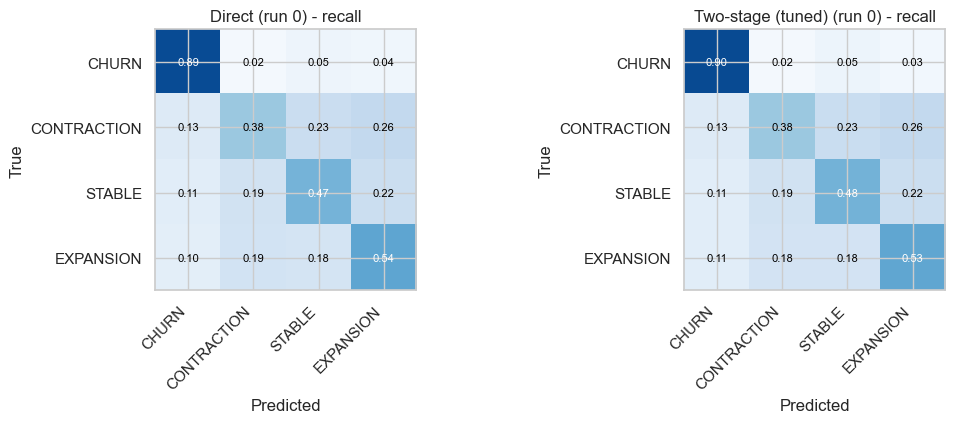

,macro_f1,balanced_acc,accuracy,weighted_f1
model,,,,
Direct LightGBM,0.4379 ± 0.0008,0.5728 ± 0.0005,0.4913 ± 0.0008,0.5186 ± 0.0008
Two-stage (arg-max),0.4150 ± 0.0006,0.5685 ± 0.0003,0.4717 ± 0.0006,0.5025 ± 0.0005
Two-stage (tuned),0.4387 ± 0.0026,0.5720 ± 0.0004,0.4928 ± 0.0022,0.5201 ± 0.0019


In [ ]:
# 7b - aggregate the 5 runs into mean +/- SE and save
runs_df = pd.DataFrame(run_records)
order = ['Direct LightGBM', 'Two-stage (arg-max)', 'Two-stage (tuned)']
metrics = ['macro_f1', 'balanced_acc', 'accuracy', 'weighted_f1']
summary = U.agg_mean_se(runs_df, 'model', metrics).set_index('model').reindex(order)
tau_mean = runs_df.loc[runs_df['model'] == 'Two-stage (tuned)', 'best_tau'].mean()

print('Per-run holdout macro-F1:')
print(runs_df.pivot(index='run', columns='model', values='macro_f1')[order].round(4))
print(f'\nMean \u00b1 SE over {len(U.RUN_SEEDS)} runs   (tuned tau mean = {tau_mean:.3f}):')
show = pd.DataFrame({
    m: summary.apply(lambda r, m=m: f"{r[f'{m}_mean']:.4f} \u00b1 {r[f'{m}_se']:.4f}", axis=1)
    for m in metrics})
print(show)

# Per-class F1 mean +/- SE per model
pc_df = pd.DataFrame(perclass_records)
pc_summary = U.agg_mean_se(pc_df, 'model', U.MODEL_CLASSES).set_index('model').reindex(order)
print('\nPer-class F1 (mean over runs):')
print(pd.DataFrame({c: pc_summary[f'{c}_mean'] for c in U.MODEL_CLASSES}).round(3))

# Persist raw per-run tables + aggregated summaries
runs_df.to_csv(U.DATA / 'clf_twostage_runs.csv', index=False)
summary.reset_index().to_csv(U.DATA / 'clf_twostage_summary.csv', index=False)
pc_df.to_csv(U.DATA / 'clf_twostage_perclass_runs.csv', index=False)
pc_summary.reset_index().to_csv(U.DATA / 'clf_twostage_perclass_summary.csv', index=False)
# backward-compatible names (now mean-over-runs)
summary.reset_index().to_csv(U.DATA / 'clf_twostage_vs_direct.csv', index=False)
pd.DataFrame({c: pc_summary[f'{c}_mean'] for c in U.MODEL_CLASSES}).round(4).to_csv(
    U.DATA / 'clf_twostage_perclass_f1.csv')

# Representative run-0 confusion: direct vs the better two-stage variant (by mean macro-F1)
best_ts_model = ('Two-stage (tuned)'
                 if summary.loc['Two-stage (tuned)', 'macro_f1_mean'] >= summary.loc['Two-stage (arg-max)', 'macro_f1_mean']
                 else 'Two-stage (arg-max)')
rep_ts_pred = rep['pred_tuned'] if best_ts_model == 'Two-stage (tuned)' else rep['pred_argmax']
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
U.plot_confusion(rep['y_multi_ho'], rep['pred_direct'], U.MODEL_CLASSES, ax=ax[0],
                 title='Direct: recall', normalize='true')
U.plot_confusion(rep['y_multi_ho'], rep_ts_pred, U.MODEL_CLASSES, ax=ax[1],
                 title=f'{best_ts_model}: recall', normalize='true')
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_twostage_confusion.png', dpi=130); plt.show()
show

## 8 · Walk-forward validation of the two-stage pipeline

Expanding window by `month_idx`: at each step refit *both* stages on
`month_idx <= t` and score the derived 4-class outcome on `t+1` (tuned tau).

train<= 0  test 1: macroF1=0.4526  balAcc=0.5143
train<= 1  test 2: macroF1=0.4488  balAcc=0.5471
train<= 2  test 3: macroF1=0.4571  balAcc=0.5646
train<= 3  test 4: macroF1=0.4321  balAcc=0.5115
train<= 4  test 5: macroF1=0.4456  balAcc=0.5715


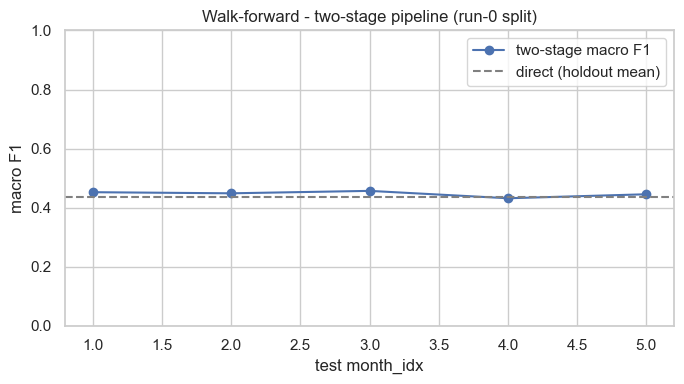

,accuracy,balanced_acc,macro_f1,weighted_f1,test_month,test_n
0,0.5146,0.5143,0.4526,0.5379,1,529419
1,0.5141,0.5471,0.4488,0.5405,2,543482
2,0.5243,0.5646,0.4571,0.5502,3,545571
3,0.5163,0.5115,0.4321,0.5448,4,551732
4,0.5055,0.5715,0.4456,0.5313,5,565623


In [ ]:
# Walk-forward is a temporal-stability diagnostic; pin to the run-0 split and its tuned params.
U.assign_run_split(df, U.RUN_SEEDS[0])
renew_params, move_params, best_tau = rep['renew_params'], rep['move_params'], rep['best_tau']
direct_holdout_f1 = summary.loc['Direct LightGBM', 'macro_f1_mean']

wf = []
for tr, tst, t in U.walk_forward_splits(df):
    s1 = make_lgbm(**renew_params).fit(X.iloc[tr], df.iloc[tr]['renewed'].to_numpy().astype(int))
    rr = np.asarray(tr)[df.iloc[tr]['renewed'].to_numpy() == 1]
    s2 = make_lgbm(**move_params).fit(X.iloc[rr], U.y_movement(df.iloc[rr]))
    pr = s1.predict_proba(X.iloc[tst])[:, 1]
    pm = s2.predict_proba(X.iloc[tst])
    pred = predict_thresh(pr, pm, best_tau)
    s = U.score_block(U.y_multiclass(df.iloc[tst]), pred)
    s['test_month'] = t + 1; s['test_n'] = len(tst); wf.append(s)
    print(f"train<= {t}  test {t+1}: macroF1={s['macro_f1']:.4f}  balAcc={s['balanced_acc']:.4f}")
wf_df = pd.DataFrame(wf)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(wf_df['test_month'], wf_df['macro_f1'], 'o-', label='two-stage macro-F1')
ax.axhline(direct_holdout_f1, ls='--', c='grey', label='direct (holdout mean)')
ax.set_xlabel('test month'); ax.set_ylabel('macro-F1'); ax.set_ylim(0, 1); ax.legend()
ax.set_title('Walk-forward stability: two-stage model')
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_twostage_walkforward.png', dpi=130); plt.show()
wf_df.round(4)

## 9 · Persist artifacts & summary

In [11]:
joblib.dump(rep['stage1'], U.DATA / 'clf_twostage_stage1_renew.joblib')   # representative run-0 fits
joblib.dump(rep['stage2'], U.DATA / 'clf_twostage_stage2_move.joblib')
wf_df.round(4).to_csv(U.DATA / 'clf_twostage_walkforward.csv', index=False)
pd.DataFrame([{'tau_mean': tau_mean, 'n_runs': len(U.RUN_SEEDS), 'seeds': str(U.RUN_SEEDS),
               **{f'renew_{k}': v for k, v in rep['renew_params'].items()},
               **{f'move_{k}': v for k, v in rep['move_params'].items()}}]).to_csv(
    U.DATA / 'clf_twostage_config.csv', index=False)
print('Saved two-stage artifacts to', U.DATA)
print('Per-seed sweeps cached:', [p.name for p in sorted(U.SWEEP_DIR.glob('twostage_*_run*.json'))])
print(f'\nHeadline (mean \u00b1 SE over {len(U.RUN_SEEDS)} runs):')
for m in order:
    print(f"  {m:22s} macro-F1 = {summary.loc[m, 'macro_f1_mean']:.4f} \u00b1 {summary.loc[m, 'macro_f1_se']:.4f}")


Saved two-stage artifacts to <repo>/KKBoxData
Per-seed sweeps cached: ['twostage_move_run42.json', 'twostage_move_run43.json', 'twostage_move_run44.json', 'twostage_move_run45.json', 'twostage_move_run46.json', 'twostage_renew_run42.json', 'twostage_renew_run43.json', 'twostage_renew_run44.json', 'twostage_renew_run45.json', 'twostage_renew_run46.json']

Headline (mean ± SE over 5 runs):
  Direct LightGBM      macro-F1 = 0.4379 ± 0.0008
  Two-stage (arg-max)    macro-F1 = 0.4150 ± 0.0006
  Two-stage (tuned)      macro-F1 = 0.4387 ± 0.0026


## 10 · Time cutoff before renewal — true cutoff (genuine rebuild)

The same true-cutoff analysis as notebook 01 (§9), applied to the **two-stage pipeline** so
we can see *which stage* the recent listening signal actually helps. This is a **genuine**
true cutoff: **every** base feature is recomputed at the decision date `E−c` directly from raw
transactions and listening logs, *as if all data in `[E−c, E)` never existed*
(`truecut_precompute.py` → `truecut_base_c{c}.parquet`). The transaction event fields become the
most recent transaction on or before `E−c`; history counts/rates, `recency_days`, `tenure_days`
and the observed-listening baseline are re-aggregated strictly before `E−c`; the listening window
ends at `E−c`. At `c = 0` the decision is at `E`, so that row provides the at-expiry diagnostic baseline for this cutoff analysis. It is separate from the five-run headline estimate.

It writes its table and plot (`clf_twostage_horizon_decay_truecut.csv` / `.png`, columns
`setting, cutoff_days, derived_macro_f1, tau, stage1_renew_f1, stage2_move_f1`) using the same
leakage-free OOF folds, cached run-0 stage params and fixed τ. Watch the Stage-1 renewal line
especially — with the transaction genuinely gone it now decays.

full data (up to E)      (n_feat=29)  derived=0.4375  s1=0.6727  s2=0.4695
cutoff E-7d (true)       (n_feat=29)  derived=0.4178  s1=0.6488  s2=0.4593
cutoff E-14d (true)      (n_feat=29)  derived=0.4025  s1=0.6384  s2=0.4455
cutoff E-30d (true)      (n_feat=29)  derived=0.3728  s1=0.6217  s2=0.4156
cutoff E-60d (true)      (n_feat=29)  derived=0.3566  s1=0.6094  s2=0.3995


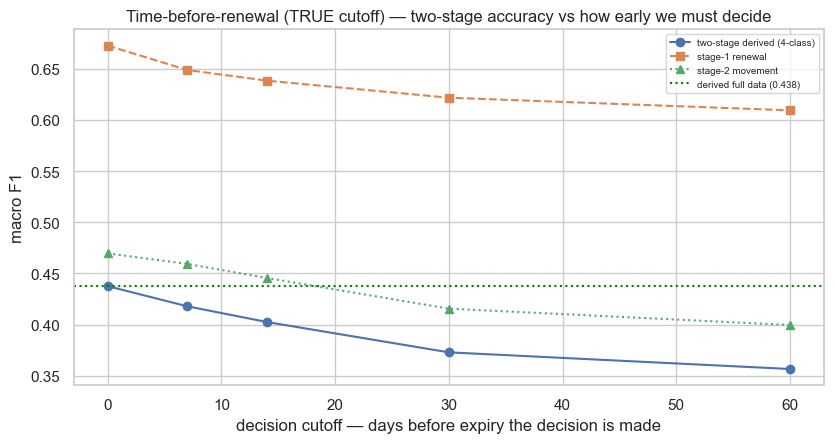

,setting,cutoff_days,derived_macro_f1,tau,stage1_renew_f1,stage2_move_f1
0,full data (up to E),0,0.4375,0.475,0.6727,0.4695
1,cutoff E-7d (true),7,0.4178,0.475,0.6488,0.4593
2,cutoff E-14d (true),14,0.4025,0.475,0.6384,0.4455
3,cutoff E-30d (true),30,0.3728,0.475,0.6217,0.4156
4,cutoff E-60d (true),60,0.3566,0.475,0.6094,0.3995


In [ ]:
import gc
# Genuine true-cutoff time-before-renewal curve for the two-stage pipeline. Every base feature is
# REBUILT at the decision date E-c from raw transactions + listening logs (truecut_precompute.py ->
# truecut_base_c{c}.parquet), i.e. "decide c days early as if all data in [E-c, E) never existed":
# event-txn fields = most recent txn <= E-c; history aggregates / recency / tenure / obs baseline all
# re-aggregated strictly before E-c; listening window ends at E-c.
from sklearn.metrics import f1_score

renew_params = U.load_sweep(f'twostage_renew_run{U.RUN_SEEDS[0]}')['best_params']
move_params  = U.load_sweep(f'twostage_move_run{U.RUN_SEEDS[0]}')['best_params']
FIXED_TAU    = float(pd.read_csv(U.DATA / 'clf_twostage_runs.csv').query('run == 0')['best_tau'].iloc[0])
CUTOFFS      = [0, 7, 14, 30, 60]

def predict_thresh(pr, pm, tau):
    mv = np.array([U.CLASS_TO_CODE[U.MOVEMENT_CLASSES[k]] for k in pm.argmax(1)])
    return np.where(pr < tau, U.CLASS_TO_CODE['CHURN'], mv)

def twostage_oof(df_s, Xc, yr, n_folds=3):
    """Leakage-free OOF stage-1 (renewal) and stage-2 (movement) probabilities."""
    opr = np.full(len(df_s), np.nan); opm = np.zeros((len(df_s), 3))
    for k, (tr, va) in enumerate(U.cv_folds(df_s)):
        if k >= n_folds:
            break
        s1 = make_lgbm(**renew_params).fit(Xc.iloc[tr], yr[tr])
        opr[va] = s1.predict_proba(Xc.iloc[va])[:, 1]
        trr = np.asarray(tr)[yr[tr] == 1]
        s2 = make_lgbm(**move_params).fit(Xc.iloc[trr], U.y_movement(df_s.iloc[trr]))
        opm[va] = s2.predict_proba(Xc.iloc[va])
    return opr, opm

def eval_cutoff(c):
    dfc = pd.read_parquet(U.DATA / f'truecut_base_c{c}.parquet')   # features rebuilt at E-c
    U.assign_run_split(dfc, U.RUN_SEEDS[0])                        # same held-out users every cutoff
    Xc  = U.build_X(dfc, 'base')
    dev = U.dev_mask(dfc)
    df_s = dfc[dev].reset_index(drop=True)
    X_s  = Xc[dev].reset_index(drop=True)
    yr   = df_s['renewed'].to_numpy().astype(int)
    ym   = U.y_multiclass(df_s)
    opr, opm = twostage_oof(df_s, X_s, yr)
    cov = ~np.isnan(opr)
    derived = f1_score(ym[cov], predict_thresh(opr[cov], opm[cov], FIXED_TAU), average='macro')
    s1f1 = f1_score(yr[cov], (opr[cov] >= 0.5).astype(int), average='macro')            # stage-1 renewal
    rmask = cov & (yr == 1)
    s2f1 = f1_score(U.y_movement(df_s[rmask]), opm[rmask].argmax(1), average='macro')    # stage-2 movement
    n_feat = X_s.shape[1]
    del dfc, Xc, df_s, X_s; gc.collect()
    name = 'full data (up to E)' if c == 0 else f'cutoff E-{c}d (true)'
    return dict(setting=name, cutoff_days=c, derived_macro_f1=derived, tau=FIXED_TAU,
                stage1_renew_f1=s1f1, stage2_move_f1=s2f1), n_feat

rows_h = []
for c in CUTOFFS:
    r, n_feat = eval_cutoff(c)
    rows_h.append(r)
    print(f"{r['setting']:24s} (n_feat={n_feat:2d})  derived={r['derived_macro_f1']:.4f}  "
          f"s1={r['stage1_renew_f1']:.4f}  s2={r['stage2_move_f1']:.4f}")

ts_horizon_df_true = pd.DataFrame(rows_h)[['setting', 'cutoff_days', 'derived_macro_f1', 'tau',
                                           'stage1_renew_f1', 'stage2_move_f1']]
ts_horizon_df_true.to_csv(U.DATA / 'clf_twostage_horizon_decay_truecut.csv', index=False)

full = ts_horizon_df_true.loc[ts_horizon_df_true['cutoff_days'] == 0, 'derived_macro_f1'].iloc[0]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(ts_horizon_df_true['cutoff_days'], ts_horizon_df_true['derived_macro_f1'], 'o-', label='two-stage derived (4-class)')
ax.plot(ts_horizon_df_true['cutoff_days'], ts_horizon_df_true['stage1_renew_f1'], 's--', label='stage-1 renewal')
ax.plot(ts_horizon_df_true['cutoff_days'], ts_horizon_df_true['stage2_move_f1'], '^:', label='stage-2 movement')
ax.axhline(full, ls=':', c='green', label=f'full data — at expiry ({full:.3f})')
ax.set_xlabel('days before expiry the decision is made'); ax.set_ylabel('macro-F1')
ax.set_title('Time before renewal: Macro-F1 vs how early the decision is made'); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_twostage_horizon_decay_truecut.png', dpi=130); plt.show()
ts_horizon_df_true.round(4)